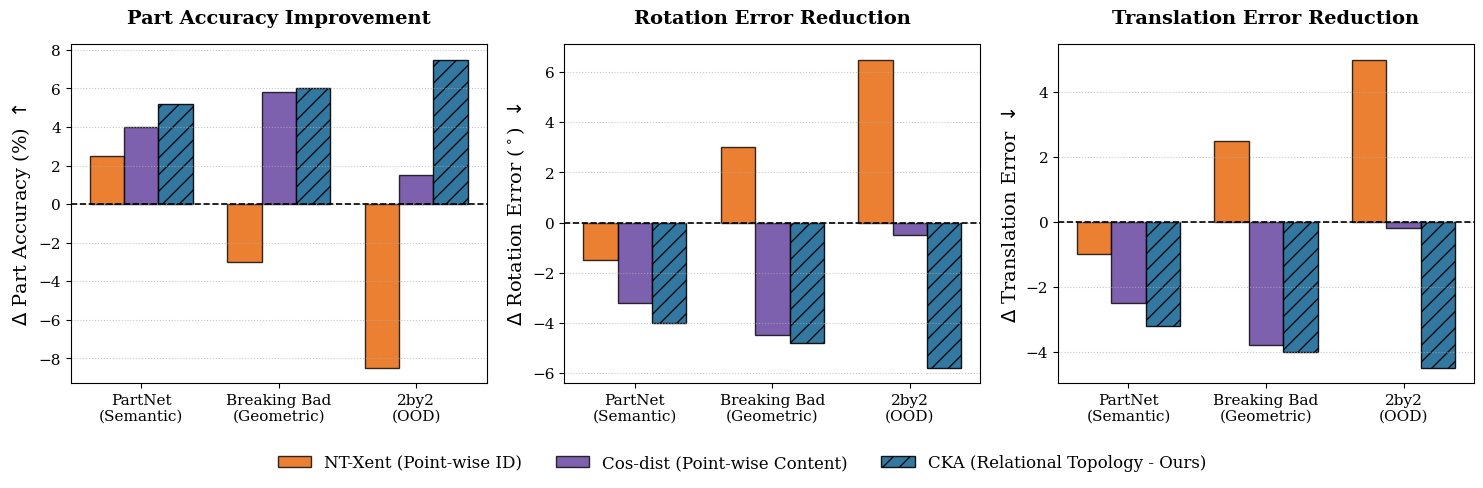

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ECCV 논문 스타일에 맞춘 폰트 및 그래프 설정
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif', # 논문용 Serif 폰트
})

# 데이터셋 라벨
datasets = ['PartNet\n(Semantic)', 'Breaking Bad\n(Geometric)', '2by2\n(OOD)']
x = np.arange(len(datasets))
width = 0.25  # 막대 두께

# 임의의(Dummy) 데이터 세팅 (Baseline RPF = 0 기준의 상대적 변화량)
# 스토리라인: 
# - NT-Xent: PartNet(성공), BB(실패-마이너스), 2by2(치명적 실패)
# - Cos-dist: PartNet(성공), BB(성공), 2by2(성능 저하/미미함)
# - CKA (Ours): 모든 데이터셋에서 일관된 높은 성능 향상

# 1. Delta Part Accuracy (높을수록 좋음, Positive is better)
pa_ntxent  = [ 2.5, -3.0, -8.5]
pa_cosdist = [ 4.0,  5.8,  1.5]
pa_cka     = [ 5.2,  6.0,  7.5]

# 2. Delta Rotation Error (낮을수록 좋음, Negative is better)
re_ntxent  = [-1.5,  3.0,  6.5]
re_cosdist = [-3.2, -4.5, -0.5]
re_cka     = [-4.0, -4.8, -5.8]

# 3. Delta Translation Error (낮을수록 좋음, Negative is better)
te_ntxent  = [-1.0,  2.5,  5.0]
te_cosdist = [-2.5, -3.8, -0.2]
te_cka     = [-3.2, -4.0, -4.5]

# 그래프 그리기 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['#E66100', '#5D3A9B', '#1D6996'] # Colorblind-friendly 팔레트 (주황, 보라, 파랑)

def plot_bar(ax, data_nt, data_cos, data_cka, title, ylabel, invert=False):
    rects1 = ax.bar(x - width, data_nt, width, label='NT-Xent (Point-wise ID)', color=colors[0], alpha=0.8, edgecolor='black')
    rects2 = ax.bar(x, data_cos, width, label='Cos-dist (Point-wise Content)', color=colors[1], alpha=0.8, edgecolor='black')
    rects3 = ax.bar(x + width, data_cka, width, label='CKA (Relational Topology - Ours)', color=colors[2], alpha=0.9, edgecolor='black', hatch='//')
    
    # Baseline (0) 라인 강조
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    
    if invert: # Error 메트릭은 아래로 가는 것이 좋으므로 축 방향을 뒤집거나 0을 기준으로 시각적 안정감 부여
        ax.invert_yaxis()

# Subplot 1: Part Accuracy
plot_bar(axes[0], pa_ntxent, pa_cosdist, pa_cka, 
         'Part Accuracy Improvement', r'$\Delta$ Part Accuracy (%) $\uparrow$')

# Subplot 2: Rotation Error (Error는 줄어드는 것(-)이 좋으므로 Y축을 뒤집어 위로 솟게 하거나 그대로 둠. 여기서는 직관성을 위해 그대로 둠)
plot_bar(axes[1], re_ntxent, re_cosdist, re_cka, 
         'Rotation Error Reduction', r'$\Delta$ Rotation Error ($^\circ$) $\downarrow$')

# Subplot 3: Translation Error
plot_bar(axes[2], te_ntxent, te_cosdist, te_cka, 
         'Translation Error Reduction', r'$\Delta$ Translation Error $\downarrow$')

# 통합 범례 (Legend) 세팅 - 중앙 하단이나 상단에 하나만 배치
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.1), frameon=False)

plt.tight_layout()
plt.show()
# plt.savefig('robustness_plot.pdf', bbox_inches='tight') # 논문 첨부용 PDF 저장

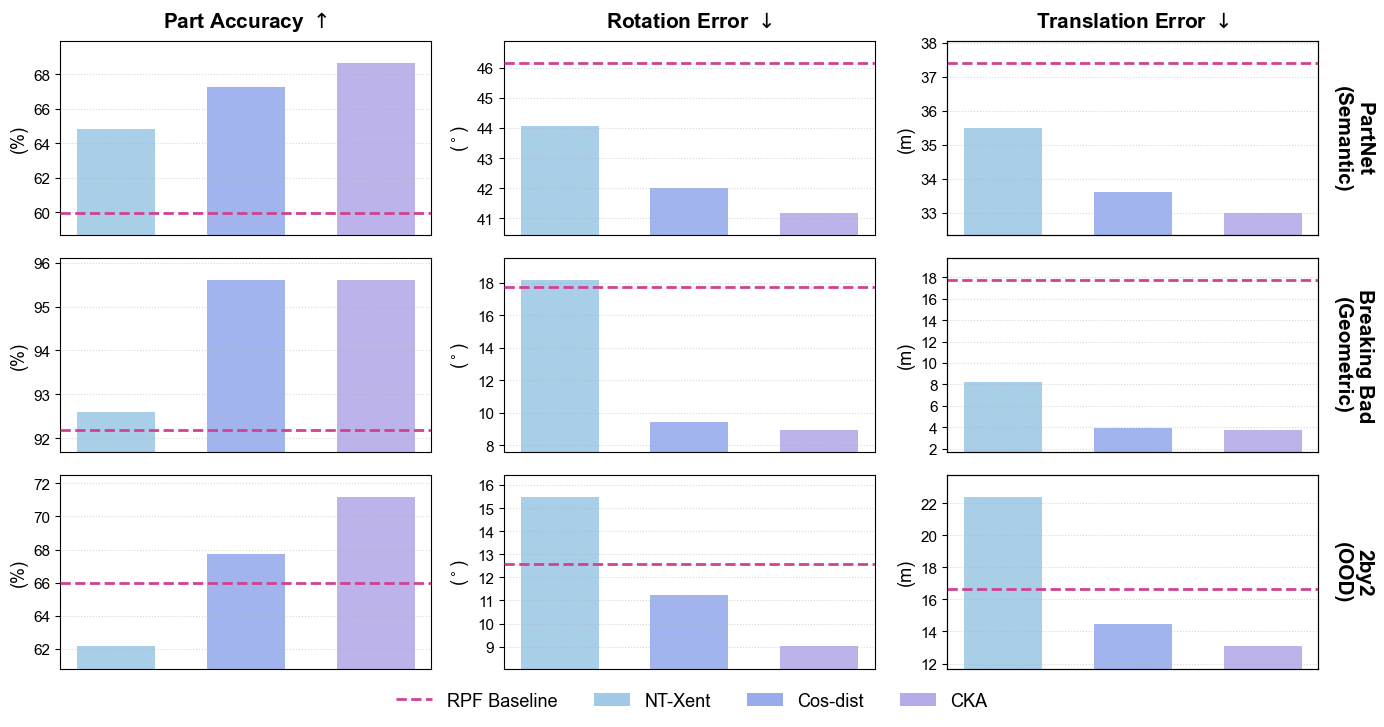

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator # 💡 정수 표기를 위한 모듈 추가
import matplotlib.font_manager as fm

# ==========================================
# 🎯 [USER CONFIGURATION] 사용자 커스텀 설정
# ==========================================
# 1. 그래프 전체 크기 및 여백 스퀴즈 조절
FIG_WIDTH = 14
FIG_HEIGHT = 7.0       # 높이를 줄여서 위아래 공간을 타이트하게 스퀴즈
SUBPLOT_H_PAD = 1.0    # 서브플롯 사이의 위아래 간격

# 2. 색상 설정 (요청하신 RGB 값을 0~1 사이로 정규화)
COLOR_NT_XENT  = (160/255, 201/255, 230/255)  # Light Blue
COLOR_COS_DIST = (151/255, 172/255, 236/255)  # Periwinkle
COLOR_CKA      = (181/255, 171/255, 232/255)  # Lavender
COLOR_BASELINE = (207/255,  66/255, 145/255)  # Magenta/Pink

# 3. 막대 테두리 설정
BAR_LINEWIDTH = 0           # 막대 테두리 완벽 제거 (0)

# ==========================================
# 💡 [FONT CHECKER] 시스템 사용 가능 폰트 확인
# 아래 세 줄의 주석을 풀고 실행하면 사용 가능한 폰트 이름들이 쭉 출력됩니다.
# ==========================================
# available_fonts = sorted([f.name for f in fm.fontManager.ttflist])
# print("--- Available Fonts ---")
# print("\n".join(set(available_fonts))) # 중복 제거 후 출력
# ==========================================

# 1. CSV 파일 불러오기
csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path) 

# 2. ECCV 논문 스타일 폰트 및 설정
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial', # 폰트를 바꾸고 싶다면 여기를 수정하세요 (예: 'Arial', 'Times New Roman')
})

# 3. 레이아웃 기본 세팅
datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles = ['PartNet\n(Semantic)', 'Breaking Bad\n(Geometric)', '2by2\n(OOD)']

metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']

# Y축 단위 라벨 (숫자가 나오므로 단위 명시)
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)'] 

# 열 제목(Column Title)에 화살표 추가
metric_titles_with_arrows = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

colors = [COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]
methods = ['NT_Xent', 'Cos_dist', 'CKA']

# 3x3 서브플롯 생성
fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, dataset in enumerate(datasets):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        
        # 데이터 필터링
        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = row['RPF_Baseline']
        vals = [row[m] for m in methods]
        
        x = np.arange(len(methods))
        
        # 막대 그래프 그리기
        bars = ax.bar(x, vals, color=colors, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)
        
        # 커스텀 색상으로 RPF 베이스라인 점선 그리기
        ax.axhline(base_val, color=COLOR_BASELINE, linestyle='--', linewidth=2, zorder=5)
        
        ax.set_xticks([]) # X축 텍스트 숨김 (이건 그대로 유지)
        
        # 💡 정수 표기(Integer ticks) 적용 로직
        if metric in ['Part Accuracy', 'Rotation Error', 'Translation Error']:
            # 지저분한 소수점 대신 정수 눈금만 표시되도록 강제
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        else:
            # Translation Error는 스케일이 작으므로 소수점 2자리로 고정
            import matplotlib.ticker as ticker
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle=':', alpha=0.5) 
        
        # 동적 Y축 범위 계산 로직
        data_min = min(base_val, min(vals))
        data_max = max(base_val, max(vals))
        value_range = data_max - data_min
        
        # 상하단 15% 여백
        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * 0.15)
        
        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2
            
        ax.set_ylim(y_min, y_max)
        
        ax.set_ylabel(metric_ylabels[j])
            
        # 맨 윗줄 열(Column) 제목에 화살표 적용
        if i == 0:
            ax.set_title(metric_titles_with_arrows[j], fontweight='bold', pad=10)
            
        # 행(Row) 제목 (맨 오른쪽)
        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(dataset_titles[i], fontweight='bold', rotation=270, labelpad=40, fontsize=15)
            ax2.set_yticks([]) # 오른쪽 제목용 더미 Y축 숫자는 안 보이게 숨김
            ax2.set_ylim(ax.get_ylim())

# 통합 범례 (Legend) 생성
custom_lines = [
    Line2D([0], [0], color=COLOR_BASELINE, linestyle='--', linewidth=2),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_NT_XENT, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_COS_DIST, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_CKA, linewidth=BAR_LINEWIDTH)
]
legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']
fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False)

# 위아래 공간 스퀴즈
plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_integers.pdf', bbox_inches='tight') # PDF 저장
plt.show()

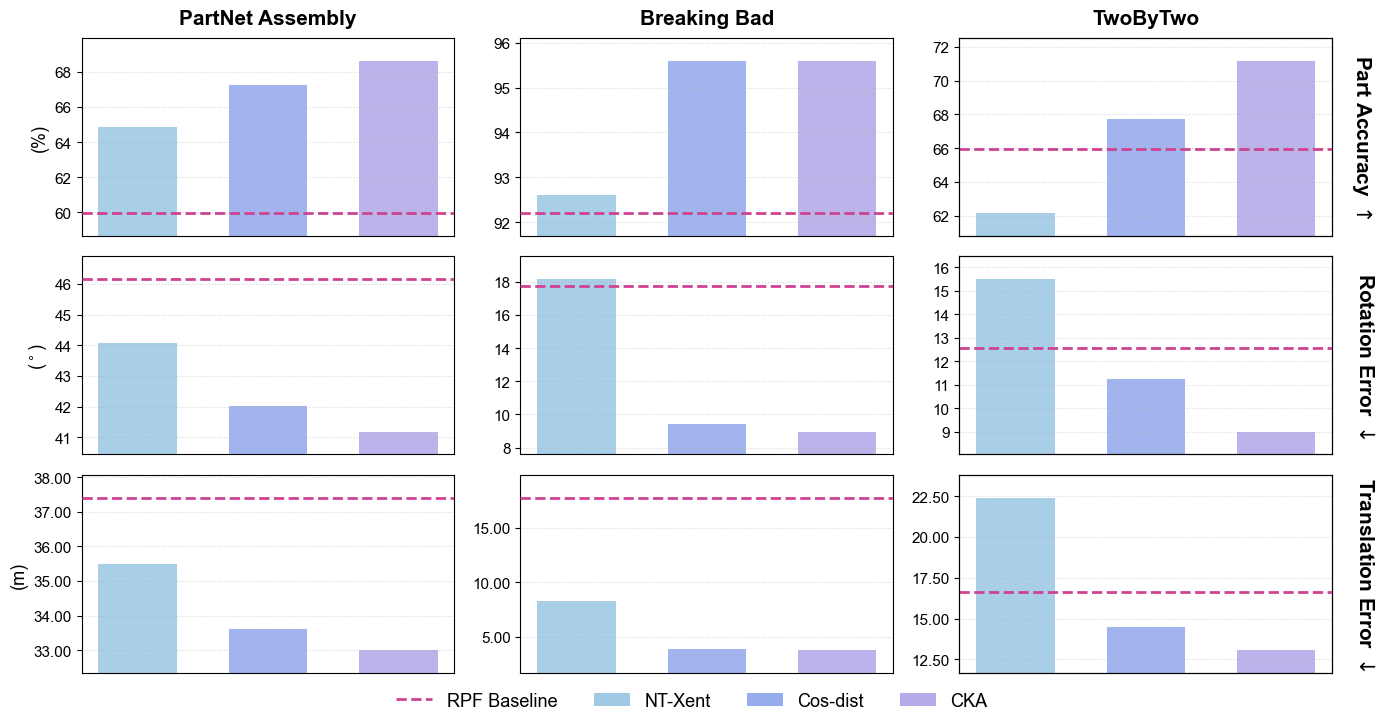

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator 
import matplotlib.font_manager as fm

# ==========================================
# 🎯 [USER CONFIGURATION] 사용자 커스텀 설정
# ==========================================
FIG_WIDTH = 14
FIG_HEIGHT = 7.0       # 높이를 줄여서 위아래 공간 스퀴즈
SUBPLOT_H_PAD = 1.0    # 서브플롯 사이의 위아래 간격

# 색상 설정 
COLOR_NT_XENT  = (160/255, 201/255, 230/255)  # Light Blue
COLOR_COS_DIST = (151/255, 172/255, 236/255)  # Periwinkle
COLOR_CKA      = (181/255, 171/255, 232/255)  # Lavender
COLOR_BASELINE = (207/255,  66/255, 145/255)  # Magenta/Pink

BAR_LINEWIDTH = 0      # 막대 테두리 제거
# ==========================================

# 1. CSV 파일 불러오기
csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path) 

# 2. ECCV 논문 스타일 폰트 및 설정
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial', # 'Arial', 'Times New Roman' 등 
})

# 3. 💡 레이아웃 기본 세팅 (축 바뀜)
# 열(Columns): 데이터셋
datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles_top = ['PartNet Assembly', 'Breaking Bad', 'TwoByTwo']

# 행(Rows): 메트릭
metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)']
metric_row_titles = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

colors = [COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]
methods = ['NT_Xent', 'Cos_dist', 'CKA']

# 💡 서브플롯 생성: 이제 i가 행(Metric), j가 열(Dataset)을 의미합니다.
fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # 데이터 필터링
        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = row['RPF_Baseline']
        vals = [row[m] for m in methods]
        
        x = np.arange(len(methods))
        
        # 막대 그래프 그리기
        bars = ax.bar(x, vals, color=colors, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)
        
        # 베이스라인 점선
        ax.axhline(base_val, color=COLOR_BASELINE, linestyle='--', linewidth=2, zorder=5)
        
        ax.set_xticks([]) # X축 텍스트 숨김
        
        # 정수 표기 및 소수점 표기 로직
        if metric in ['Part Accuracy', 'Rotation Error']:
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        else:
            import matplotlib.ticker as ticker
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle=':', alpha=0.5) 
        
        # 동적 Y축 범위 계산
        data_min = min(base_val, min(vals))
        data_max = max(base_val, max(vals))
        value_range = data_max - data_min
        
        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * 0.15)
        
        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2
            
        ax.set_ylim(y_min, y_max)
        
        # 💡 Y축 단위 라벨은 맨 왼쪽 열(j == 0)에만 표시
        if j == 0:
            ax.set_ylabel(metric_ylabels[i])
            
        # 💡 맨 윗줄(i == 0) 열(Column) 제목: 데이터셋 이름
        if i == 0:
            ax.set_title(dataset_titles_top[j], fontweight='bold', pad=10)
            
        # 💡 맨 오른쪽 열(j == 2) 행(Row) 제목: 메트릭 이름과 화살표
        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(metric_row_titles[i], fontweight='bold', rotation=270, labelpad=30, fontsize=15)
            ax2.set_yticks([]) 
            ax2.set_ylim(ax.get_ylim())

# 통합 범례 (Legend) 생성
custom_lines = [
    Line2D([0], [0], color=COLOR_BASELINE, linestyle='--', linewidth=2),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_NT_XENT, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_COS_DIST, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_CKA, linewidth=BAR_LINEWIDTH)
]
legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']
fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False)

# 위아래 공간 스퀴즈
plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_version2_transposed.pdf', bbox_inches='tight') # PDF 저장
plt.show()

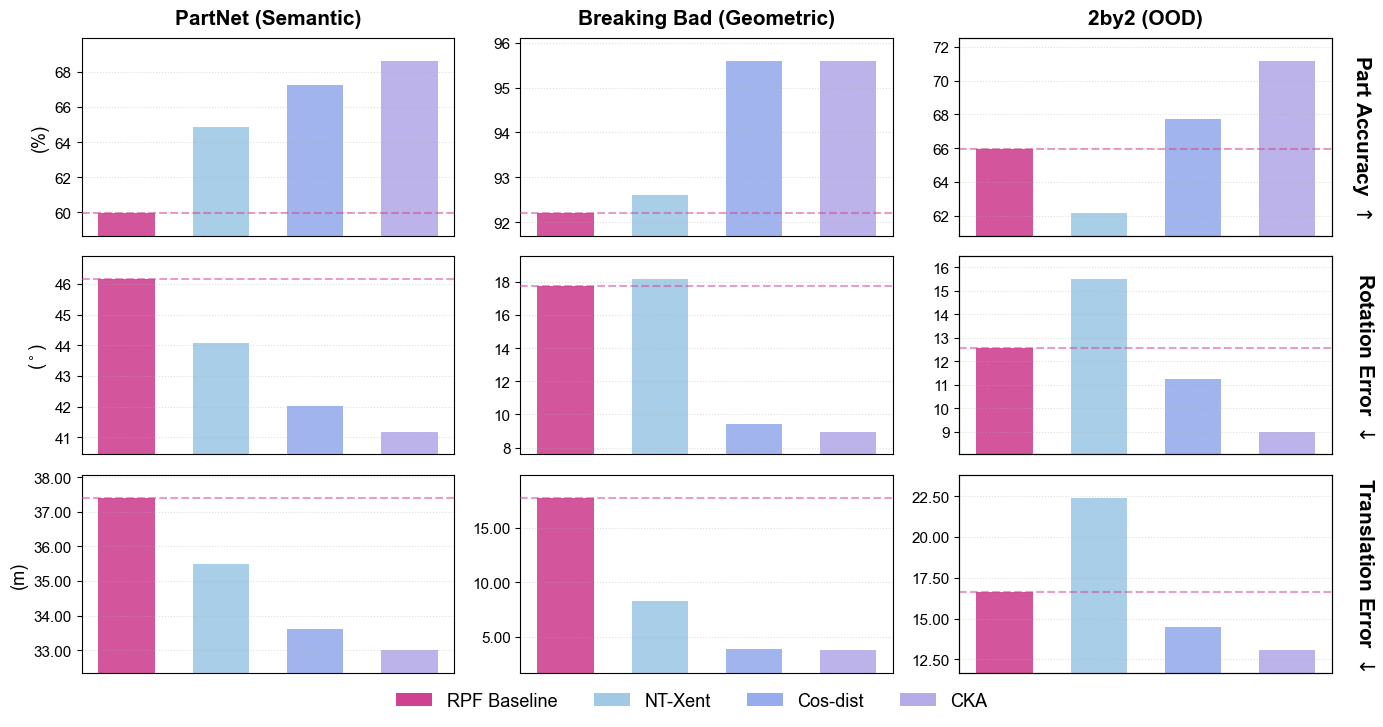

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator 
import matplotlib.font_manager as fm

# ==========================================
# 🎯 [USER CONFIGURATION] 사용자 커스텀 설정
# ==========================================
FIG_WIDTH = 14
FIG_HEIGHT = 7.0       # 높이를 줄여서 위아래 공간 스퀴즈
SUBPLOT_H_PAD = 1.0    # 서브플롯 사이의 위아래 간격

# 색상 설정 
COLOR_BASELINE = (207/255,  66/255, 145/255)  # Magenta/Pink (RPF Baseline)
COLOR_NT_XENT  = (160/255, 201/255, 230/255)  # Light Blue
COLOR_COS_DIST = (151/255, 172/255, 236/255)  # Periwinkle
COLOR_CKA      = (181/255, 171/255, 232/255)  # Lavender

BAR_LINEWIDTH = 0      # 막대 테두리 제거
# ==========================================

# 1. CSV 파일 불러오기
csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path) 

# 2. ECCV 논문 스타일 폰트 및 설정
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial', # 'Arial', 'Times New Roman' 등 
})

# 3. 레이아웃 기본 세팅
datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles_top = ['PartNet (Semantic)', 'Breaking Bad (Geometric)', '2by2 (OOD)']

metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)']
metric_row_titles = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

# 베이스라인이 첫 번째 막대로 들어갑니다.
methods = ['RPF_Baseline', 'NT_Xent', 'Cos_dist', 'CKA']
colors = [COLOR_BASELINE, COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]

# 서브플롯 생성: i가 행(Metric), j가 열(Dataset)
fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # 데이터 필터링
        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = row['RPF_Baseline']
        vals = [row[m] for m in methods]
        
        x = np.arange(len(methods))
        
        # 막대 그래프 그리기 (총 4개의 막대)
        bars = ax.bar(x, vals, color=colors, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)
        
        # 💡 연한 베이스라인 점선 추가 (linewidth와 alpha를 조절하여 부드럽게)
        ax.axhline(base_val, color=COLOR_BASELINE, linestyle='--', linewidth=1.5, alpha=0.5, zorder=4)
        
        ax.set_xticks([]) # X축 텍스트 숨김
        
        # 정수 표기 및 소수점 표기 로직
        if metric in ['Part Accuracy', 'Rotation Error']:
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        else:
            import matplotlib.ticker as ticker
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle=':', alpha=0.4) 
        
        # 동적 Y축 범위 계산 (모든 막대 중 최소/최대값 기준)
        data_min = min(vals)
        data_max = max(vals)
        value_range = data_max - data_min
        
        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * 0.15)
        
        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2
            
        ax.set_ylim(y_min, y_max)
        
        # Y축 단위 라벨은 맨 왼쪽 열(j == 0)에만 표시
        if j == 0:
            ax.set_ylabel(metric_ylabels[i])
            
        # 맨 윗줄(i == 0) 열(Column) 제목: 데이터셋 이름
        if i == 0:
            ax.set_title(dataset_titles_top[j], fontweight='bold', pad=10)
            
        # 맨 오른쪽 열(j == 2) 행(Row) 제목: 메트릭 이름과 화살표
        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(metric_row_titles[i], fontweight='bold', rotation=270, labelpad=30, fontsize=15)
            ax2.set_yticks([]) 
            ax2.set_ylim(ax.get_ylim())

# 통합 범례 (Legend) 생성 (베이스라인도 점선이 아닌 막대 모양으로)
custom_lines = [
    plt.Rectangle((0,0),1,1, facecolor=COLOR_BASELINE, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_NT_XENT, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_COS_DIST, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_CKA, linewidth=BAR_LINEWIDTH)
]
legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']
fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False)

# 위아래 공간 스퀴즈
plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_bars_with_line.pdf', bbox_inches='tight') # PDF 저장
plt.show()

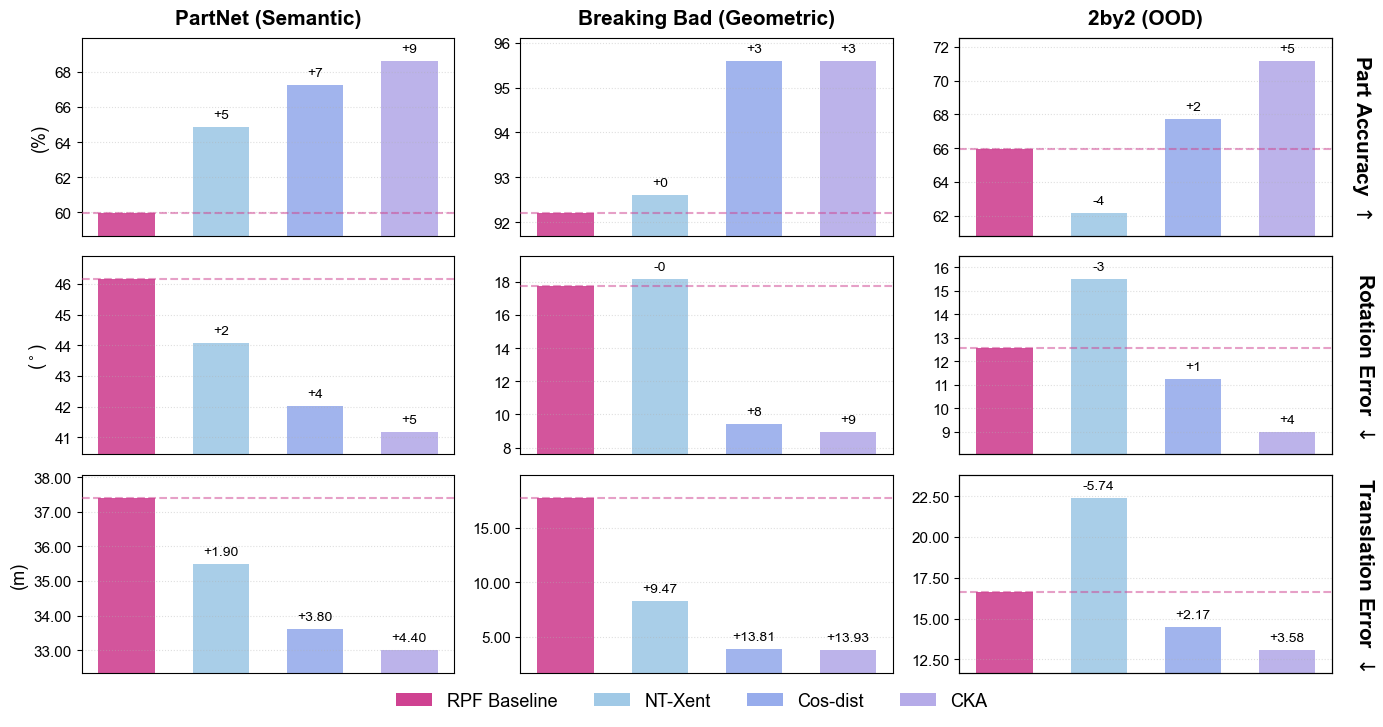

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker

# ==========================================
# 🎯 [USER CONFIGURATION] 사용자 커스텀 설정
# ==========================================
FIG_WIDTH = 14
FIG_HEIGHT = 7.0
SUBPLOT_H_PAD = 1.0

# 색상 설정
COLOR_BASELINE = (207/255,  66/255, 145/255)  # Magenta/Pink (RPF Baseline)
COLOR_NT_XENT  = (160/255, 201/255, 230/255)  # Light Blue
COLOR_COS_DIST = (151/255, 172/255, 236/255)  # Periwinkle
COLOR_CKA      = (181/255, 171/255, 232/255)  # Lavender

BAR_LINEWIDTH = 0

# Δ 표시 설정
SHOW_DELTA_TEXT = True
DELTA_FONTSIZE = 10
DELTA_Y_OFFSET = 0.03  # y-range 대비 오프셋 비율
# ==========================================

# 1. CSV 파일 불러오기
csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path)

# 2. 폰트 및 설정
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial',
})

# 3. 레이아웃 기본 세팅
datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles_top = ['PartNet (Semantic)', 'Breaking Bad (Geometric)', '2by2 (OOD)']

metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)']
metric_row_titles = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

methods = ['RPF_Baseline', 'NT_Xent', 'Cos_dist', 'CKA']
colors = [COLOR_BASELINE, COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]

# metric 방향: True면 높을수록 좋음(↑), False면 낮을수록 좋음(↓)
higher_is_better_map = {
    'Part Accuracy': True,
    'Rotation Error': False,
    'Translation Error': False
}

fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]

        # 데이터 필터링
        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = float(row['RPF_Baseline'])
        vals = [float(row[m]) for m in methods]

        x = np.arange(len(methods))

        # 막대 그래프
        bars = ax.bar(x, vals, color=colors, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)

        # 베이스라인 점선
        ax.axhline(base_val, color=COLOR_BASELINE, linestyle='--', linewidth=1.5, alpha=0.5, zorder=4)

        ax.set_xticks([])

        # y tick 포맷
        if metric in ['Part Accuracy', 'Rotation Error']:
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        else:
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle=':', alpha=0.4)

        # y-lim
        data_min = min(vals)
        data_max = max(vals)
        value_range = data_max - data_min

        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * 0.15)

        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2

        ax.set_ylim(y_min, y_max)

        # ✅ Δ 텍스트 (baseline 대비 "개선량"을 +로)
        if SHOW_DELTA_TEXT:
            higher_is_better = higher_is_better_map[metric]
            y_range = y_max - y_min
            for k, (b, v) in enumerate(zip(bars, vals)):
                if k == 0:
                    continue  # baseline은 Δ 생략

                raw_delta = v - base_val
                improvement = raw_delta if higher_is_better else -raw_delta  # error는 줄어들면 +로

                # 포맷
                if metric in ['Part Accuracy', 'Rotation Error']:
                    txt = f"{improvement:+.0f}"
                else:
                    txt = f"{improvement:+.2f}"

                ax.text(
                    b.get_x() + b.get_width()/2,
                    v + y_range * DELTA_Y_OFFSET,
                    txt,
                    ha='center', va='bottom',
                    fontsize=DELTA_FONTSIZE
                )

        # 라벨/타이틀
        if j == 0:
            ax.set_ylabel(metric_ylabels[i])

        if i == 0:
            ax.set_title(dataset_titles_top[j], fontweight='bold', pad=10)

        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(metric_row_titles[i], fontweight='bold', rotation=270, labelpad=30, fontsize=15)
            ax2.set_yticks([])
            ax2.set_ylim(ax.get_ylim())

# 범례
custom_lines = [
    plt.Rectangle((0,0),1,1, facecolor=COLOR_BASELINE, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_NT_XENT, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_COS_DIST, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_CKA, linewidth=BAR_LINEWIDTH)
]
legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']
fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_bars_with_delta_text.pdf', bbox_inches='tight')
plt.show()

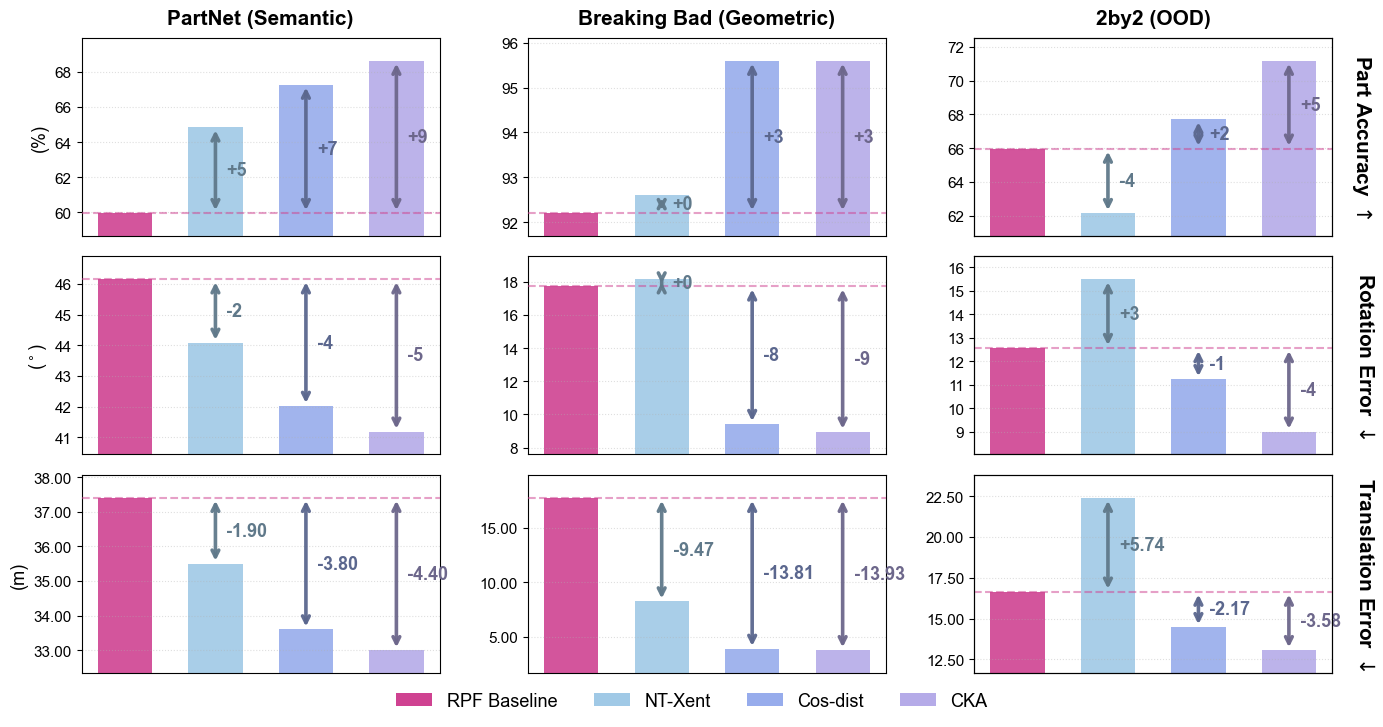

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker

# ==========================================
# 🎯 USER CONFIGURATION
# ==========================================
FIG_WIDTH = 14
FIG_HEIGHT = 7.0
SUBPLOT_H_PAD = 1.0

COLOR_BASELINE = (207/255, 66/255, 145/255)
COLOR_NT_XENT  = (160/255, 201/255, 230/255)
COLOR_COS_DIST = (151/255, 172/255, 236/255)
COLOR_CKA      = (181/255, 171/255, 232/255)

BAR_LINEWIDTH = 0

ARROW_LW = 2.6
ARROW_ALPHA = 0.95

DELTA_FONTSIZE = 13   # 🔥 더 크게
DELTA_X_OFFSET = 0.12 # 🔥 화살표 오른쪽으로 이동 비율
# ==========================================


def darken_color(color, factor=0.6):
    return tuple(max(min(c * factor, 1), 0) for c in color)


csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial',
})

datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles_top = ['PartNet (Semantic)', 'Breaking Bad (Geometric)', '2by2 (OOD)']

metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)']
metric_row_titles = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

methods = ['RPF_Baseline', 'NT_Xent', 'Cos_dist', 'CKA']
colors = [COLOR_BASELINE, COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]

fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]

        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = float(row['RPF_Baseline'])
        vals = [float(row[m]) for m in methods]

        x = np.arange(len(methods))
        bars = ax.bar(x, vals, color=colors, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)

        ax.axhline(base_val, color=COLOR_BASELINE,
                   linestyle='--', linewidth=1.5,
                   alpha=0.5, zorder=3)

        ax.set_xticks([])

        if metric in ['Part Accuracy', 'Rotation Error']:
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        else:
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle=':', alpha=0.4)

        data_min = min(vals)
        data_max = max(vals)
        value_range = data_max - data_min

        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * 0.15)

        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2

        ax.set_ylim(y_min, y_max)
        y_range = y_max - y_min

        # ======================================
        # 🔥 수직 양방향 화살표 + 오른쪽 Bold 숫자
        # ======================================
        for k in range(1, len(bars)):
            bar = bars[k]
            x_center = bar.get_x() + bar.get_width()/2
            y_top = bar.get_height()

            delta = vals[k] - base_val  # raw delta

            if metric in ['Part Accuracy', 'Rotation Error']:
                txt = f"{delta:+.0f}"
            else:
                txt = f"{delta:+.2f}"

            arrow_color = darken_color(colors[k], factor=0.6)

            # 양방향 수직 화살표
            ax.annotate(
                "",
                xy=(x_center, y_top),
                xytext=(x_center, base_val),
                arrowprops=dict(
                    arrowstyle="<->",
                    lw=ARROW_LW,
                    color=arrow_color,
                    alpha=ARROW_ALPHA
                ),
                zorder=5
            )

            # 🔥 숫자를 오른쪽으로 이동
            y_mid = (base_val + y_top) / 2.0

            ax.text(
                x_center + DELTA_X_OFFSET,   # 🔥 오른쪽 이동
                y_mid,
                txt,
                ha='left',
                va='center',
                fontsize=DELTA_FONTSIZE,
                fontweight='bold',           # 🔥 Bold
                color=arrow_color
            )

        if j == 0:
            ax.set_ylabel(metric_ylabels[i])

        if i == 0:
            ax.set_title(dataset_titles_top[j], fontweight='bold', pad=10)

        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(metric_row_titles[i],
                           fontweight='bold',
                           rotation=270,
                           labelpad=30,
                           fontsize=15)
            ax2.set_yticks([])
            ax2.set_ylim(ax.get_ylim())

custom_lines = [
    plt.Rectangle((0,0),1,1, facecolor=COLOR_BASELINE, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_NT_XENT, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_COS_DIST, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_CKA, linewidth=BAR_LINEWIDTH)
]

legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']

fig.legend(custom_lines, legend_labels,
           loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05),
           frameon=False)

plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_vertical_double_head_arrows_rightText.pdf',
            bbox_inches='tight')
plt.show()

/var/folders/t4/fkf6x0s9771c38y7pz0r8jhr0000gn/T/ipykernel_69802/257927548.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=SUBPLOT_H_PAD)


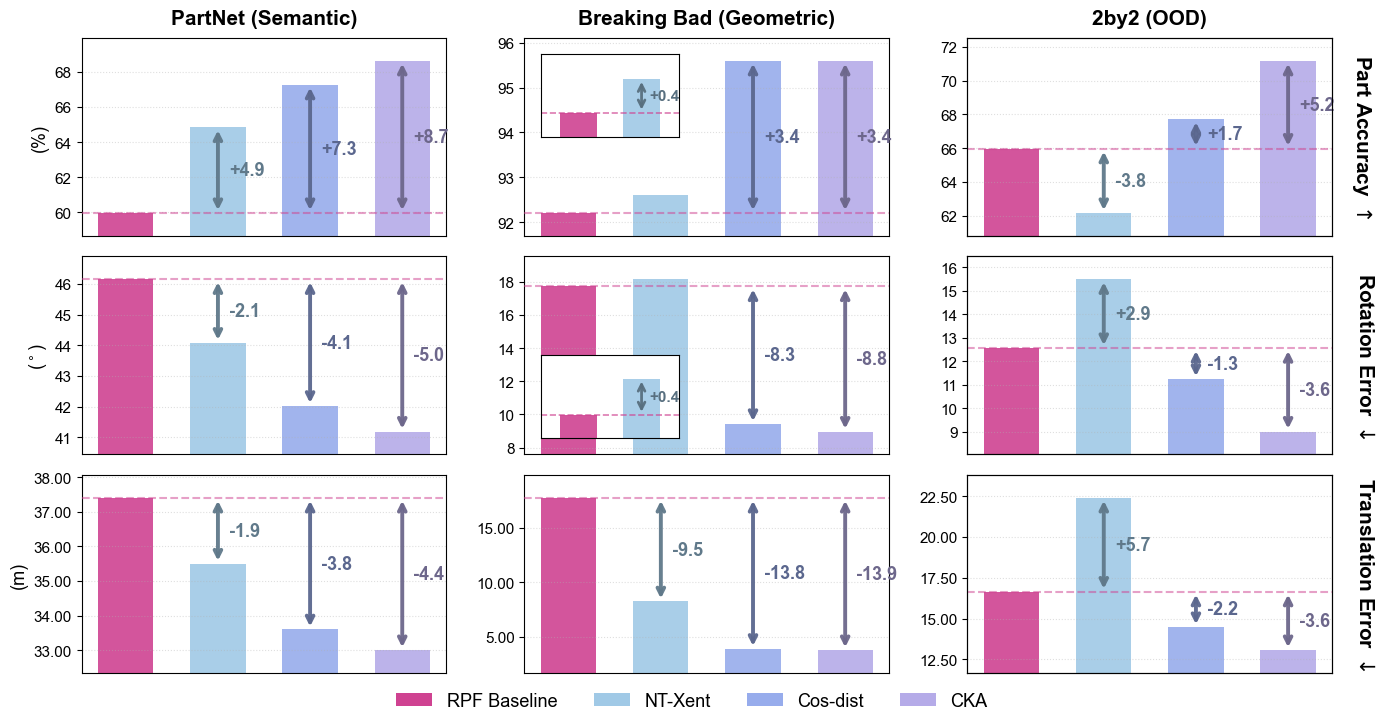

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================
# 🎯 USER CONFIGURATION
# ==========================================
FIG_WIDTH = 14
FIG_HEIGHT = 7.0
SUBPLOT_H_PAD = 1.0

COLOR_BASELINE = (207/255, 66/255, 145/255)
COLOR_NT_XENT  = (160/255, 201/255, 230/255)
COLOR_COS_DIST = (151/255, 172/255, 236/255)
COLOR_CKA      = (181/255, 171/255, 232/255)

BAR_LINEWIDTH = 0

# Main arrow/text
MAIN_ARROW_LW = 2.8
MAIN_ARROW_ALPHA = 0.95
MAIN_DELTA_FONTSIZE = 13
DELTA_X_OFFSET = 0.12

# --- Zoom inset settings ---
ENABLE_ZOOM_INSET = True

# "작은 Δ" 판정 (raw delta 기준, 필요하면 조절)
ZOOM_DELTA_THRESH_INT = 0.6
ZOOM_DELTA_THRESH_FLOAT = 0.02

INSET_W = "38%"
INSET_H = "42%"
INSET_BORDERPAD = 0.9

# inset y축 확대 강도
INSET_Y_PAD_RATIO = 0.12
INSET_MIN_SPAN_INT = 0.8
INSET_MIN_SPAN_FLOAT = 0.02

# inset 전용 스타일
INSET_ARROW_LW = 2.0
INSET_ARROW_ALPHA = 0.95
INSET_DELTA_FONTSIZE = 11
INSET_HIDE_YTICKS = True
# ==========================================


def darken_color(color, factor=0.6):
    return tuple(max(min(c * factor, 1), 0) for c in color)

def is_int_metric(metric: str) -> bool:
    return metric in ['Part Accuracy', 'Rotation Error']

def delta_fmt_1dec(d: float) -> str:
    # ✅ 모든 Δ는 소수점 1자리 고정
    return f"{d:+.1f}"

def choose_left_inset_loc(focus_vals, y_min, y_max):
    """
    inset을 무조건 왼쪽에 두되,
    focus가 상단을 많이 차지하면 lower left로 내려서 가림 최소화.
    """
    y_range = max(1e-9, (y_max - y_min))
    focus_top_ratio = (max(focus_vals) - y_min) / y_range
    avoid_top = (focus_top_ratio > 0.72)
    return "lower left" if avoid_top else "upper left"


# CSV
csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial',
})

datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles_top = ['PartNet (Semantic)', 'Breaking Bad (Geometric)', '2by2 (OOD)']

metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)']
metric_row_titles = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

methods = ['RPF_Baseline', 'NT_Xent', 'Cos_dist', 'CKA']
colors = [COLOR_BASELINE, COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]

fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]

        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = float(row['RPF_Baseline'])
        vals = [float(row[m]) for m in methods]

        x = np.arange(len(methods))
        bars = ax.bar(x, vals, color=colors, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)

        # baseline line
        ax.axhline(base_val, color=COLOR_BASELINE, linestyle='--',
                   linewidth=1.5, alpha=0.5, zorder=3)

        ax.set_xticks([])

        # main y tick format은 기존 유지 (Δ 표기는 1자리로 별개 처리)
        if is_int_metric(metric):
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        else:
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle=':', alpha=0.4)

        # main y-lim
        data_min = min(vals)
        data_max = max(vals)
        value_range = data_max - data_min
        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * 0.15)
        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2
        ax.set_ylim(y_min, y_max)

        # raw deltas
        deltas = [vals[k] - base_val for k in range(len(vals))]

        # small delta threshold (metric별)
        zoom_thresh = ZOOM_DELTA_THRESH_INT if is_int_metric(metric) else ZOOM_DELTA_THRESH_FLOAT
        small_idx = [k for k in range(1, len(vals)) if abs(deltas[k]) <= zoom_thresh]
        has_small = (len(small_idx) > 0)

        # ---------------------------
        # ✅ Main arrows: "small_idx 제외"하고 나머지는 그대로 그림
        # ---------------------------
        for k in range(1, len(bars)):
            if ENABLE_ZOOM_INSET and (k in small_idx):
                continue  # inset으로 보낼 애들: main 화살표/Δ 제거

            bar = bars[k]
            x_center = bar.get_x() + bar.get_width()/2
            y_top = bar.get_height()

            delta = deltas[k]
            txt = delta_fmt_1dec(delta)  # ✅ 1 decimal
            arrow_color = darken_color(colors[k], factor=0.6)

            ax.annotate(
                "",
                xy=(x_center, y_top),
                xytext=(x_center, base_val),
                arrowprops=dict(
                    arrowstyle="<->",
                    lw=MAIN_ARROW_LW,
                    color=arrow_color,
                    alpha=MAIN_ARROW_ALPHA
                ),
                zorder=5
            )

            y_mid = (base_val + y_top) / 2.0
            ax.text(
                x_center + DELTA_X_OFFSET, y_mid,
                txt,
                ha='left', va='center',
                fontsize=MAIN_DELTA_FONTSIZE,
                fontweight='bold',
                color=arrow_color,
                zorder=6
            )

        # ---------------------------
        # ✅ Zoom inset: baseline + small bars ONLY
        #    (연결선/박스 없음)
        # ---------------------------
        if ENABLE_ZOOM_INSET and has_small:
            focus_idx = sorted(set([0] + small_idx))

            # inset y-lim 강하게 확대 (focus min/max 기준)
            focus_vals_for_ylim = [base_val] + [vals[k] for k in small_idx]
            y_low = min(focus_vals_for_ylim)
            y_high = max(focus_vals_for_ylim)
            span = (y_high - y_low)

            min_span = INSET_MIN_SPAN_INT if is_int_metric(metric) else INSET_MIN_SPAN_FLOAT
            span = max(span, min_span)

            pad = span * INSET_Y_PAD_RATIO
            mid = (y_low + y_high) / 2.0
            inset_ymin = mid - span/2 - pad
            inset_ymax = mid + span/2 + pad

            # inset은 왼쪽(upper/lower left)
            inset_loc = choose_left_inset_loc(
                focus_vals=[vals[k] for k in focus_idx],
                y_min=y_min, y_max=y_max
            )

            axins = inset_axes(
                ax, width=INSET_W, height=INSET_H,
                loc=inset_loc, borderpad=INSET_BORDERPAD
            )

            xf = np.array(focus_idx)
            vf = [vals[k] for k in focus_idx]
            cf = [colors[k] for k in focus_idx]

            axins.bar(xf, vf, color=cf, alpha=0.9, width=0.6, linewidth=BAR_LINEWIDTH)
            axins.axhline(base_val, color=COLOR_BASELINE, linestyle='--', linewidth=1.2, alpha=0.7)

            axins.set_xlim(min(focus_idx) - 0.6, max(focus_idx) + 0.6)
            axins.set_ylim(inset_ymin, inset_ymax)
            axins.set_xticks([])

            # inset y축 숫자 제거
            if INSET_HIDE_YTICKS:
                axins.set_yticks([])
                axins.tick_params(left=False, labelleft=False)

            axins.grid(axis='y', linestyle=':', alpha=0.20)

            # inset: small bars만 화살표 + Δ (얇게/작게)
            for k in small_idx:
                x_center = k
                y_top = vals[k]
                delta = deltas[k]
                txt = delta_fmt_1dec(delta)  # ✅ 1 decimal

                arrow_color = darken_color(colors[k], factor=0.55)

                axins.annotate(
                    "",
                    xy=(x_center, y_top),
                    xytext=(x_center, base_val),
                    arrowprops=dict(
                        arrowstyle="<->",
                        lw=INSET_ARROW_LW,
                        color=arrow_color,
                        alpha=INSET_ARROW_ALPHA
                    ),
                    zorder=5
                )

                y_mid = (base_val + y_top) / 2.0
                axins.text(
                    x_center + DELTA_X_OFFSET, y_mid,
                    txt,
                    ha='left', va='center',
                    fontsize=INSET_DELTA_FONTSIZE,
                    fontweight='bold',
                    color=arrow_color,
                    zorder=6
                )

        # Labels / Titles
        if j == 0:
            ax.set_ylabel(metric_ylabels[i])

        if i == 0:
            ax.set_title(dataset_titles_top[j], fontweight='bold', pad=10)

        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(metric_row_titles[i],
                           fontweight='bold',
                           rotation=270,
                           labelpad=30,
                           fontsize=15)
            ax2.set_yticks([])
            ax2.set_ylim(ax.get_ylim())

# Legend
custom_lines = [
    plt.Rectangle((0,0), 1, 1, facecolor=COLOR_BASELINE, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0), 1, 1, facecolor=COLOR_NT_XENT, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0), 1, 1, facecolor=COLOR_COS_DIST, linewidth=BAR_LINEWIDTH),
    plt.Rectangle((0,0), 1, 1, facecolor=COLOR_CKA, linewidth=BAR_LINEWIDTH),
]
legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']
fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_inset_no_connectors_main_arrows_except_small.pdf', bbox_inches='tight')
plt.show()

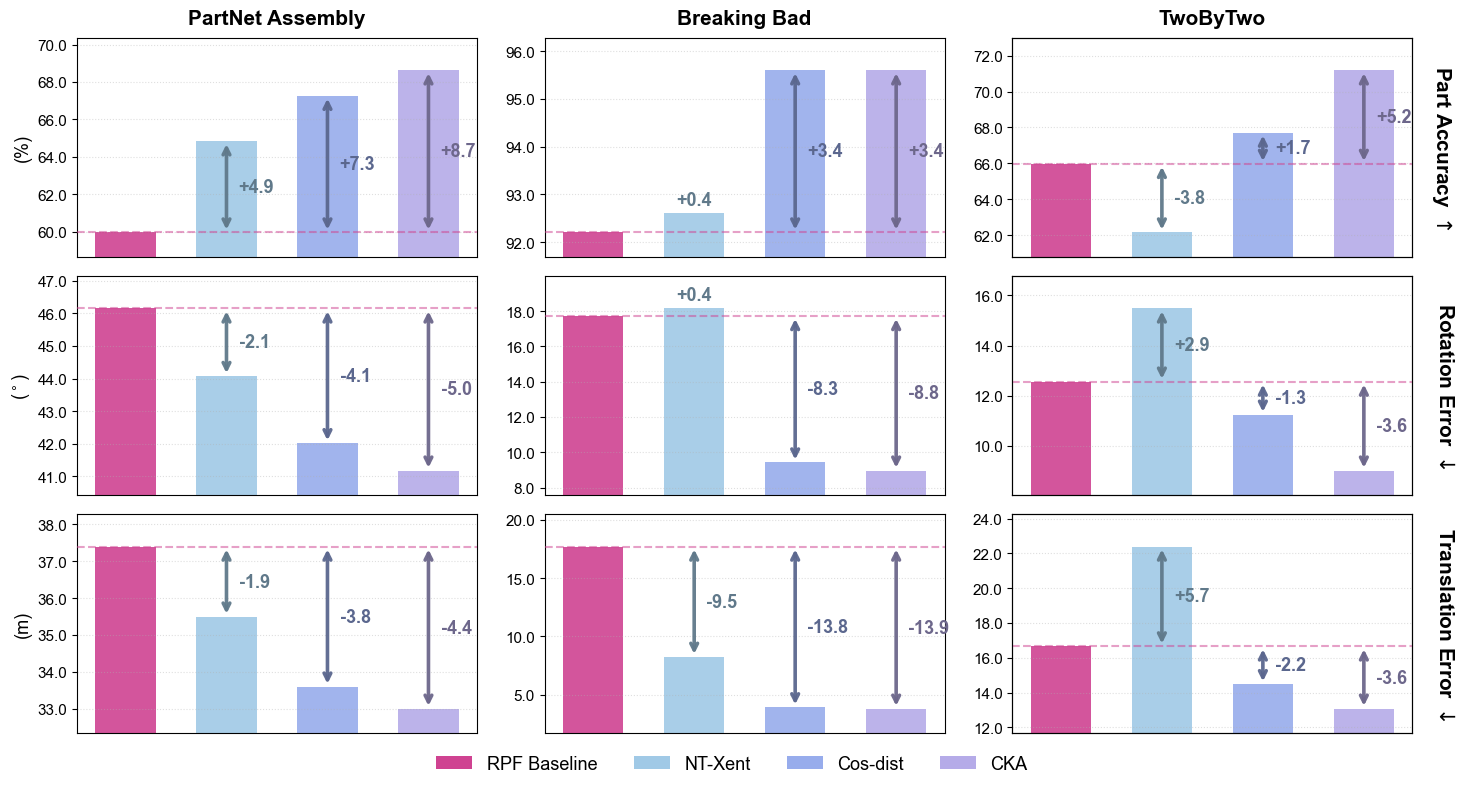

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# ==========================================
# 🎯 USER CONFIGURATION
# ==========================================
FIG_WIDTH = 14.8
FIG_HEIGHT = 7.6
SUBPLOT_H_PAD = 1.1

COLOR_BASELINE = (207/255, 66/255, 145/255)
COLOR_NT_XENT  = (160/255, 201/255, 230/255)
COLOR_COS_DIST = (151/255, 172/255, 236/255)
COLOR_CKA      = (181/255, 171/255, 232/255)

BAR_LINEWIDTH = 0

ARROW_LW = 2.6
ARROW_ALPHA = 0.95

DELTA_FONTSIZE = 13
DELTA_X_OFFSET = 0.12

SMALL_DELTA_THRESH_INT = 0.6
SMALL_DELTA_THRESH_FLOAT = 0.02
SMALL_TEXT_FONTSIZE = 13
SMALL_TEXT_Y_PAD_RATIO = 0.02   # 🔥 살짝 아래로 (기존 0.03)

# 🔥 텍스트가 테두리에 걸리지 않게 "항상" 위쪽 마진 확보
TOP_TEXT_SAFE_MARGIN_RATIO = 0.02  # y-range의 2% 만큼은 항상 위 테두리에서 띄움

# 🔥 y_max 여유를 아주 조금 더 줘서 상단 공간 확보
YMAX_PAD_MULT = 0.20  # 기존 0.15 -> 0.20
# ==========================================


def darken_color(color, factor=0.6):
    return tuple(max(min(c * factor, 1), 0) for c in color)

def fmt_delta_1dec(delta: float) -> str:
    return f"{delta:+.1f}"


csv_path = 'csv/results.csv'
df = pd.read_csv(csv_path)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'legend.fontsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'Arial',
})

datasets = ['PartNet', 'Breaking Bad', '2by2']
dataset_titles_top = ['PartNet Assembly', 'Breaking Bad', 'TwoByTwo']

metrics = ['Part Accuracy', 'Rotation Error', 'Translation Error']
metric_ylabels = [r'(%)', r'($^\circ$)', r'(m)']
metric_row_titles = [r'Part Accuracy $\uparrow$', r'Rotation Error $\downarrow$', r'Translation Error $\downarrow$']

methods = ['RPF_Baseline', 'NT_Xent', 'Cos_dist', 'CKA']
colors = [COLOR_BASELINE, COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA]

fig, axes = plt.subplots(3, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]

        row = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)].iloc[0]
        base_val = float(row['RPF_Baseline'])
        vals = [float(row[m]) for m in methods]

        x = np.arange(len(methods))
        bars = ax.bar(x, vals, color=colors, alpha=0.9,
                      width=0.6, linewidth=BAR_LINEWIDTH)

        ax.axhline(base_val, color=COLOR_BASELINE,
                   linestyle='--', linewidth=1.5,
                   alpha=0.5, zorder=3)

        ax.set_xticks([])

        # ✅ 모든 y축을 소수점 1자리로 통일
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

        ax.grid(axis='y', linestyle=':', alpha=0.4)

        data_min = min(vals)
        data_max = max(vals)
        value_range = data_max - data_min

        y_min = max(0, data_min - (value_range * 0.15))
        y_max = data_max + (value_range * YMAX_PAD_MULT)  # 🔥 0.15 -> 0.20

        if value_range == 0:
            y_min = max(0, data_min * 0.8)
            y_max = data_max * 1.2

        ax.set_ylim(y_min, y_max)
        y_range = y_max - y_min

        small_thresh = SMALL_DELTA_THRESH_INT if metric in ['Part Accuracy', 'Rotation Error'] else SMALL_DELTA_THRESH_FLOAT

        # 위 테두리 안전 마진 (이 이상으로는 텍스트가 올라가지 않도록 clamp)
        y_text_cap = y_max - y_range * TOP_TEXT_SAFE_MARGIN_RATIO

        for k in range(1, len(bars)):
            bar = bars[k]
            x_center = bar.get_x() + bar.get_width()/2
            y_top = bar.get_height()

            delta = vals[k] - base_val
            txt = fmt_delta_1dec(delta)
            arrow_color = darken_color(colors[k], factor=0.6)

            if abs(delta) <= small_thresh:
                # ✅ small delta: 화살표 없이 막대 위 Δ
                #    (하지만 위 테두리에 걸리면 자동으로 살짝 내려오게 clamp)
                y_text = y_top + y_range * SMALL_TEXT_Y_PAD_RATIO
                y_text = min(y_text, y_text_cap)  # 🔥 clamp

                ax.text(
                    x_center,
                    y_text,
                    txt,
                    ha='center',
                    va='bottom',
                    fontsize=SMALL_TEXT_FONTSIZE,
                    fontweight='bold',
                    color=arrow_color,
                    zorder=6
                )
                continue

            # 큰 delta: 수직 양방향 화살표
            ax.annotate(
                "",
                xy=(x_center, y_top),
                xytext=(x_center, base_val),
                arrowprops=dict(
                    arrowstyle="<->",
                    lw=ARROW_LW,
                    color=arrow_color,
                    alpha=ARROW_ALPHA
                ),
                zorder=5
            )

            # Δ 텍스트: 화살표 오른쪽 (이것도 혹시 모를 상단 걸침 방지)
            y_mid = (base_val + y_top) / 2.0
            y_mid = min(y_mid, y_text_cap)  # 🔥 아주 드물지만 안전하게

            ax.text(
                x_center + DELTA_X_OFFSET,
                y_mid,
                txt,
                ha='left',
                va='center',
                fontsize=DELTA_FONTSIZE,
                fontweight='bold',
                color=arrow_color,
                zorder=6
            )

        if j == 0:
            ax.set_ylabel(metric_ylabels[i])

        if i == 0:
            ax.set_title(dataset_titles_top[j],
                         fontweight='bold', pad=10)

        if j == 2:
            ax2 = ax.twinx()
            ax2.set_ylabel(metric_row_titles[i],
                           fontweight='bold',
                           rotation=270,
                           labelpad=30,
                           fontsize=15)
            ax2.set_yticks([])
            ax2.set_ylim(ax.get_ylim())

custom_lines = [
    plt.Rectangle((0,0),1,1, facecolor=COLOR_BASELINE),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_NT_XENT),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_COS_DIST),
    plt.Rectangle((0,0),1,1, facecolor=COLOR_CKA)
]

legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA']

fig.legend(custom_lines, legend_labels,
           loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05),
           frameon=False)

plt.tight_layout(h_pad=SUBPLOT_H_PAD)
plt.savefig('main_results_3x3_uniform_1decimal_larger_safeText.pdf',
            bbox_inches='tight')
plt.show()